In [21]:
# imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [56]:
# Task 1: Load and clean the Data

def load_and_clean_data(file_path="AB_NYC_2019.csv"):
    
    #load Airbnb dataset and clean it by removing rows with missing values and filtering out listings with price less than 0
    

    # load the dataset
    df = pd.read_csv(file_path)
    print("Initial shape:", df.shape)

    # show any missing values
    print("\nMissing values before cleaning:")
    print(df.isnull().sum())

    # drop any rows with missing critical info
    df = df.dropna(subset=['name', 'host_name', 'reviews_per_month'])

   

    # remove listings with price <= 0
    df = df[df['price'] > 0]

    # reseet index
    df.reset_index(drop=True, inplace=True)

    # display results
    print("\nshape after cleaning:", df.shape)
    print("\nmissing values after cleaning:")
    print(df.isnull().sum())

    return df


To clean the Airbnb dataset for analysis, I dropped rows that were missing important information in the `name`, `host_name`, or `reviews_per_month` columns. These fields are essential for analysis of listings and host activity. I also excluded listings with a `price` less than or equal to 0, as this could affect average pricing analyses. After cleaning, I reset the index to keep the dataset clean and avoid any issues.



In [23]:
load_and_clean_data()

Initial shape: (48895, 16)

Missing values before cleaning:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Shape after cleaning: (38811, 16)

Missing values after cleaning:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
lati

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
3,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
4,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38806,36425863,Lovely Privet Bedroom with Privet Restroom,83554966,Rusaa,Manhattan,Upper East Side,40.78099,-73.95366,Private room,129,1,1,2019-07-07,1.00,1,147
38807,36427429,No.2 with queen size bed,257683179,H Ai,Queens,Flushing,40.75104,-73.81459,Private room,45,1,1,2019-07-07,1.00,6,339
38808,36438336,Seas The Moment,211644523,Ben,Staten Island,Great Kills,40.54179,-74.14275,Private room,235,1,1,2019-07-07,1.00,1,87
38809,36442252,1B-1B apartment near by Metro,273841667,Blaine,Bronx,Mott Haven,40.80787,-73.92400,Entire home/apt,100,1,2,2019-07-07,2.00,1,40


In [24]:
df_clean = load_and_clean_data()


Initial shape: (48895, 16)

Missing values before cleaning:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Shape after cleaning: (38811, 16)

Missing values after cleaning:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
lati

In [69]:
# Task 2 Part A group by neighborhood and count listings

# filter to neighborhoods with more than 5 listings
valid_neighborhoods = neighborhood_counts[neighborhood_counts > 5].index
df_filtered = df_clean[df_clean['neighbourhood'].isin(valid_neighborhoods)]

# calculate average price per neighborhood
avg_price_by_neighborhood = df_filtered.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

#  5 most expensive neighborhoods
top_5 = avg_price_by_neighborhood.head(5)
print("Top 5 Most Expensive Neighborhoods:")
print(top_5)

#  Bottom 5 expensive neighborhoods
bottom_5 = avg_price_by_neighborhood.tail(5)
print("\nBottom 5 Least Expensive Neighborhoods:")
print(bottom_5)


Top 5 Most Expensive Neighborhoods:
neighbourhood
Tribeca              460.300000
NoHo                 298.451613
Flatiron District    291.482759
SoHo                 281.303136
Midtown              267.583164
Name: price, dtype: float64

Bottom 5 Least Expensive Neighborhoods:
neighbourhood
Corona         56.932203
Soundview      52.846154
Bronxdale      51.875000
Hunts Point    51.812500
Tremont        49.900000
Name: price, dtype: float64


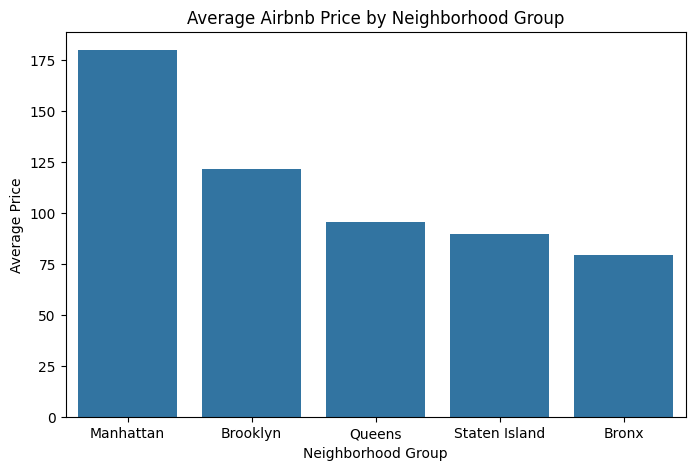

In [73]:
# Task 2 Part B group data by neighborhood group and calculate the average price for each group
avg_price_by_group = df_clean.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

# setup the figure size for the plot
plt.figure(figsize=(8, 5))

# I chose to create a bar plot of average price by neighborhood group
sns.barplot(x=avg_price_by_group.index, y=avg_price_by_group.values)

# add  title and axis labels for clarity
plt.title("Average Airbnb Price by Neighborhood Group")
plt.xlabel("Neighborhood Group")
plt.ylabel("Average Price")

# Display the plot
plt.show()


In [96]:
# Task 3 Do a pairwise Pearson correlation analysis to show most positive and negative correlations

#get only numeric columns
numeric_data = df_clean.select_dtypes(include='number')

# compute full correlation matrix
corr_matrix = numeric_data.corr()

# flatten it for comparison (skip self-correlation)
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# drop duplicates 
corr_pairs = corr_pairs.drop_duplicates().sort_values()

# show most negative correlations
print("Most Negative Correlations:")
print(corr_pairs.head(5))

# show most positive correlations
print("\nMost Positive Correlations:")
print(corr_pairs.tail(5))


Most Negative Correlations:
id              number_of_reviews                -0.330063
longitude       price                            -0.155199
host_id         number_of_reviews                -0.142055
minimum_nights  reviews_per_month                -0.121653
longitude       calculated_host_listings_count   -0.093356
dtype: float64

Most Positive Correlations:
number_of_reviews  availability_365     0.193363
id                 reviews_per_month    0.291820
host_id            reviews_per_month    0.296252
number_of_reviews  reviews_per_month    0.549594
id                 host_id              0.591509
dtype: float64


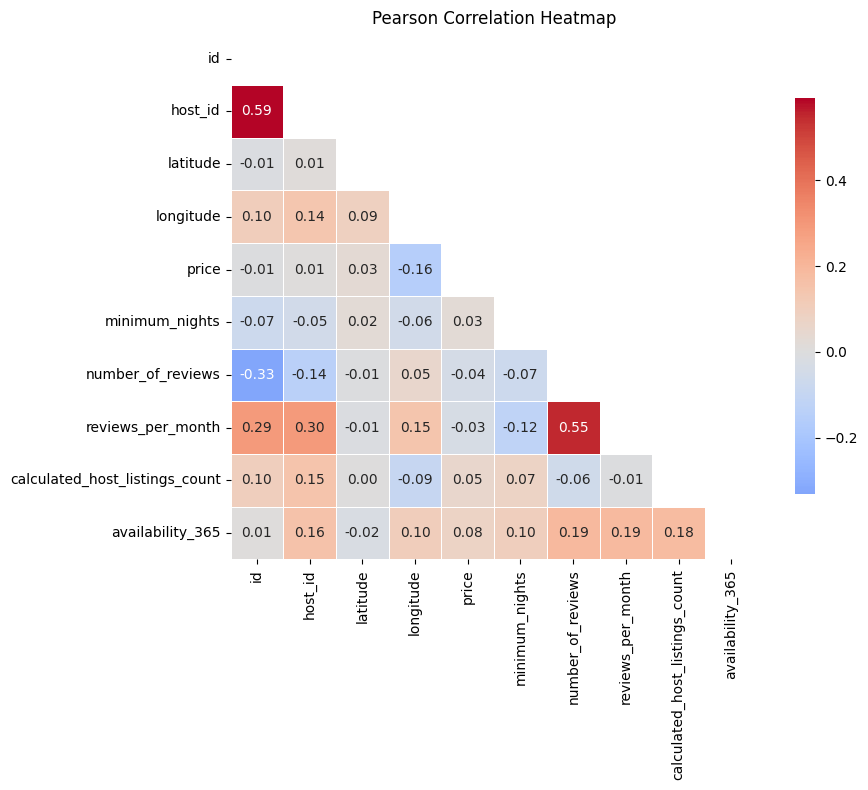

In [97]:
#Task 3 compute correlation matrix and display heatmap
corr_matrix = df_clean.select_dtypes(include='number').corr()

# create a mask to show the lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# setup the figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,                   # apply  mask
    annot=True,                  # show correlation values
    fmt=".2f",                   # format decimals
    cmap='coolwarm',             # color palette
    center=0,                    # center color at 0
    square=True,                 # keep the cells square
    linewidths=0.5,              # add lines between cells
    cbar_kws={'shrink': 0.75}    # shrink the colorbar
)
# do the labels
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()


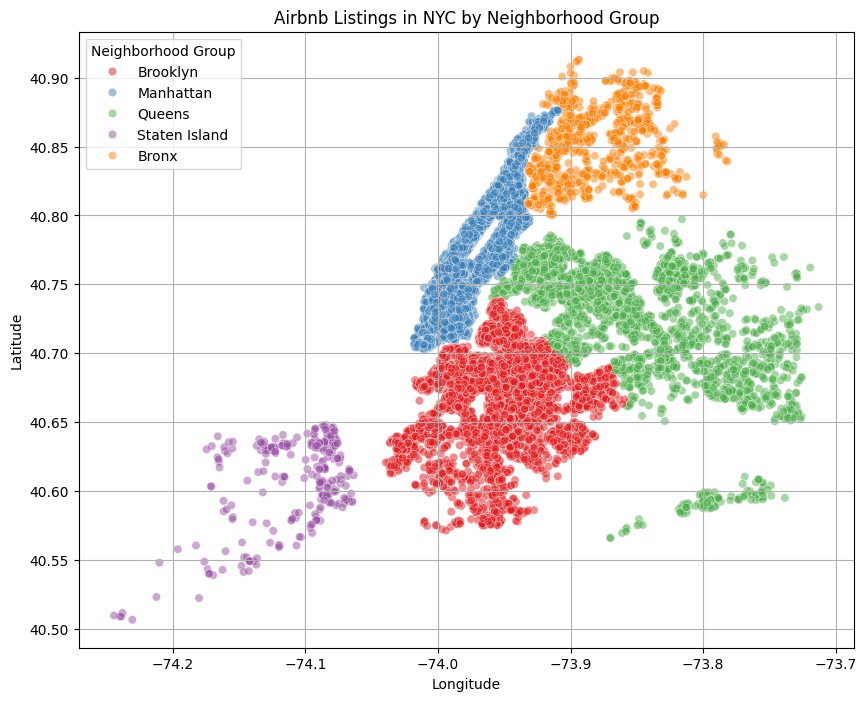

In [103]:
#Task 4
# set the figure size for the scatter plot
plt.figure(figsize=(10, 8))

# create a scatter plot of Airbnb listings
# each point is a listing, colored by neighborhood group
sns.scatterplot(
    x='longitude',               # longitude on the x-axis
    y='latitude',                # latitude on the y-axis
    hue='neighbourhood_group',  # color-code points by borough
    data=df_clean,              # Use the cleaned dataset
    palette='Set1',             # Choose a color palette
    alpha=0.5                   # Set transparency to reduce overlap
)

# add a title and axis labels
plt.title("Airbnb Listings in NYC by Neighborhood Group")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# add a legend with a custom title
plt.legend(title='Neighborhood Group')

# show grid lines for  readability
plt.grid(True)

# display final plot
plt.show()


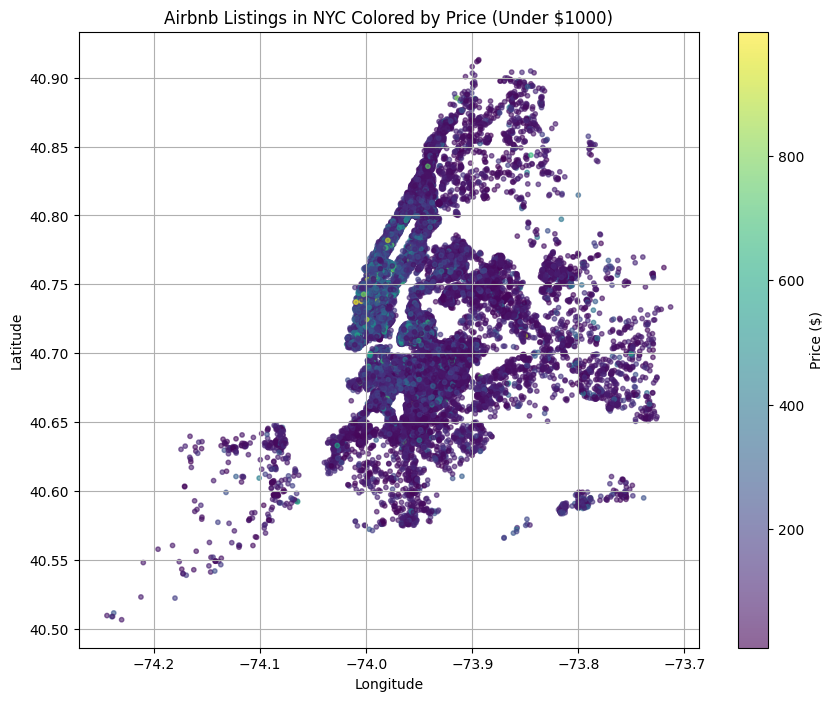

In [83]:
#Task 4b
plt.figure(figsize=(10, 8))

# Filter for prices under $1000
filtered_df = df_clean[df_clean['price'] < 1000]

# create scatter plot colored by price across locations
scatter = plt.scatter(
    x=filtered_df['longitude'],
    y=filtered_df['latitude'],
    c=filtered_df['price'],
    cmap='viridis',
    alpha=0.6,
    s=10
)

# label the plot
plt.colorbar(scatter, label='Price ($)')
plt.title("Airbnb Listings in NYC Colored by Price (Under $1000)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


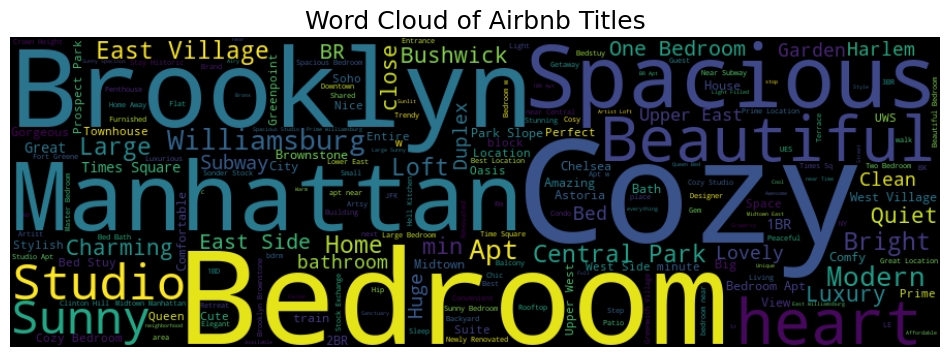

In [51]:
# Task 5 wordcloud
from wordcloud import WordCloud, STOPWORDS

# combine all Airbnb listing names into one string
text = " ".join(df_clean['name'].dropna().astype(str))


# generate the word cloud
wordcloud = WordCloud(
    width=900,
    height=300,
    background_color='black',
    stopwords=stopwords,
    colormap='viridis'
).generate(text)

# display it
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Airbnb Titles", fontsize=18)
plt.show()


In [84]:
#Task 6 Find areas with busiest hosts 
# count number of listings per host and print
top_hosts = df_clean['host_id'].value_counts().head(5)
print("Top 5 Hosts by Listings:")
print(top_hosts)


Top 5 Hosts by Listings:
host_id
219517861    207
61391963      79
16098958      61
137358866     51
7503643       49
Name: count, dtype: int64


In [37]:
#Task 6 find areas for top 5 highest listing hosts 
#filter data to listings from the top 5 hosts
busiest_hosts_df = df_clean[df_clean['host_id'].isin(top_hosts.index)]

# group by host and neighborhood group
location_counts = busiest_hosts_df.groupby(['host_id', 'neighbourhood_group']).size().unstack(fill_value=0)
print("Listing Distribution of Top Hosts by Neighborhood Group:")
print(location_counts)


Listing Distribution of Top Hosts by Neighborhood Group:
neighbourhood_group  Brooklyn  Manhattan  Queens
host_id                                         
7503643                    49          0       0
16098958                    0         61       0
61391963                    0         79       0
137358866                   2         13      36
219517861                   0        207       0


In [38]:
#Task 6 get stats for each of the top hosts
summary_stats = busiest_hosts_df.groupby('host_id')[
    ['price', 'availability_365', 'number_of_reviews', 'reviews_per_month']
].mean()

print("Summary Stats for Busiest Hosts:")
print(summary_stats)


Summary Stats for Busiest Hosts:
                price  availability_365  number_of_reviews  reviews_per_month
host_id                                                                      
7503643    149.408163        301.979592           4.938776           0.101224
16098958   198.032787        297.639344           2.262295           0.119672
61391963   144.620253        241.405063           5.278481           0.268101
137358866   43.823529        205.921569           1.705882           0.444706
219517861  270.144928        288.362319           6.188406           1.920580


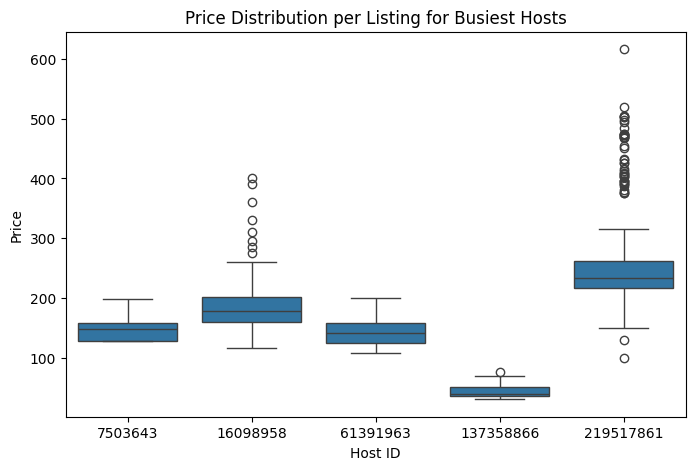

In [89]:
#Task 6 create a blot showing price distribution for the busiest hosts
#Set the figure size for the plot
plt.figure(figsize=(8, 5))

# create a box plot to show the distribution of prices per host
# each box represents the spread of prices for one of the busiest hosts
sns.boxplot(
    x='host_id',    # host IDs on the x-axis (top 5 busiest hosts)
    y='price',      # price on the y-axis
    data=busiest_hosts_df  # use only the listings from the busiest hosts
)

# add a title to the plot
plt.title("Price Distribution per Listing for Busiest Hosts")

# label the x-axis
plt.xlabel("Host ID")

# label the y-axis
plt.ylabel("Price")

# display the plot
plt.show()


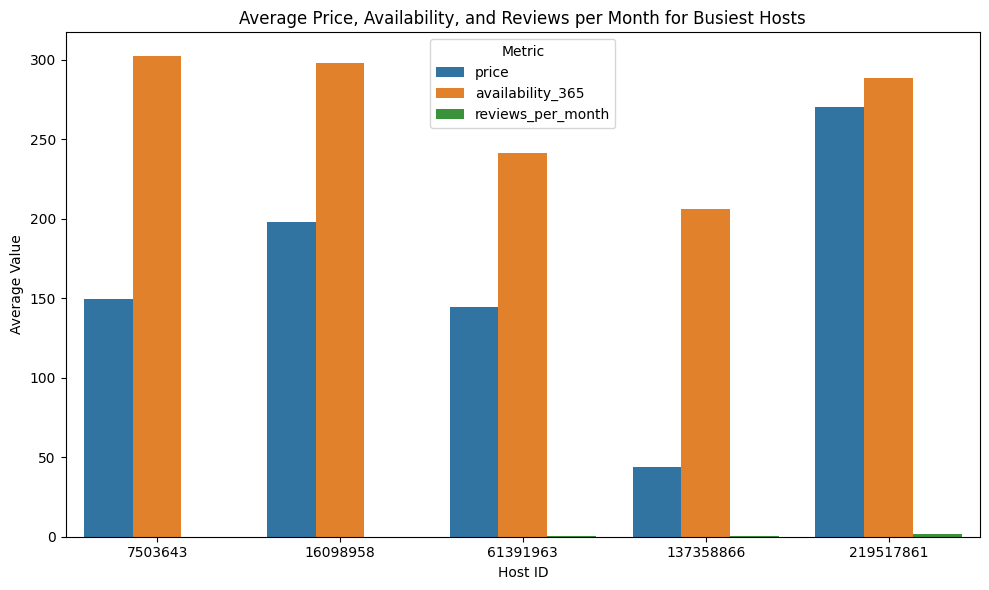

In [91]:
#Task 6 display price, availability, and reviews for busiest hosts
#get average metrics for each top host
avg_stats = busiest_hosts_df.groupby('host_id')[['price', 'availability_365', 'reviews_per_month']].mean()

# reset index for plotting
avg_stats = avg_stats.reset_index()

# melt the dataframe to long format for seaborn
melted_stats = avg_stats.melt(id_vars='host_id', var_name='Metric', value_name='Average Value')

# plot grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='host_id', y='Average Value', hue='Metric', data=melted_stats)

plt.title("Average Price, Availability, and Reviews per Month for Busiest Hosts")
plt.xlabel("Host ID")
plt.ylabel("Average Value")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


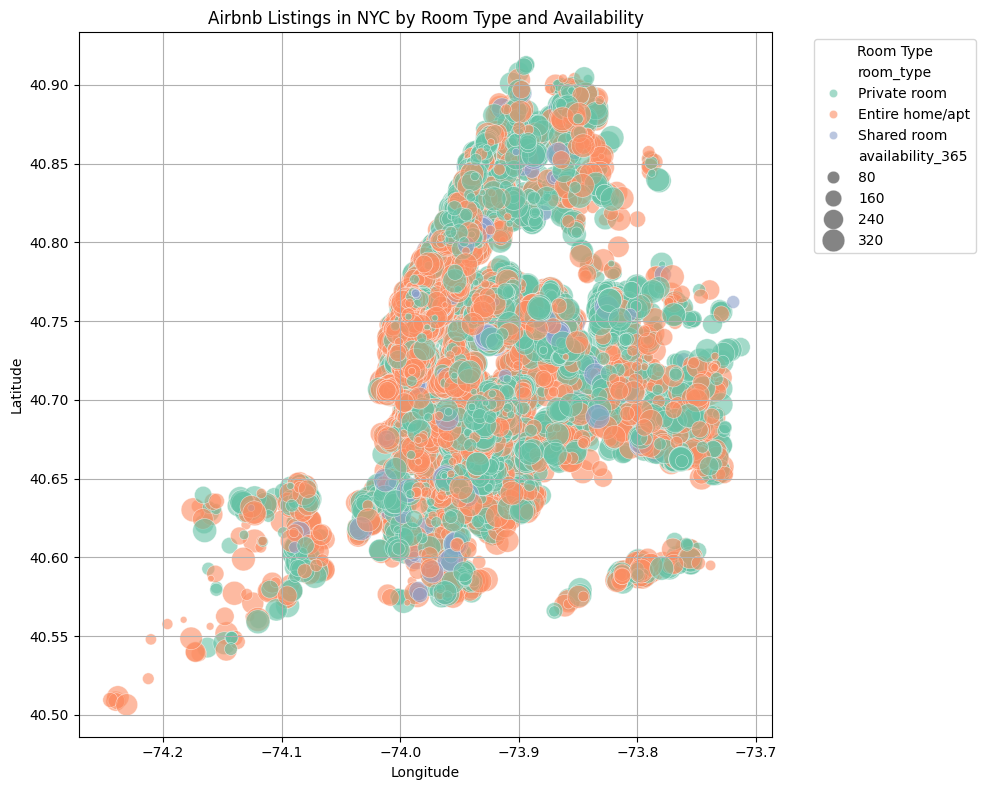

In [99]:
#Task 7 Plot 1
# Set the figure size
plt.figure(figsize=(10, 8))

# Filter out listings that have zero availability (optional)
filtered_df = df_clean[df_clean['availability_365'] > 0]

# create a scatter plot to visualize listings across NYC
# - X and Y show location 
# - Color shows room type
# - Size shows availability (days/year)
sns.scatterplot(
    x='longitude',                # Longitude on x-axis
    y='latitude',                 # Latitude on y-axis
    hue='room_type',              # Color based on room type
    size='availability_365',      # Size of dot based on availability
    data=filtered_df,             # Filtered dataset
    palette='Set2',               # A visually distinct color palette
    alpha=0.6,                    # Slight transparency
    sizes=(20, 300)               # Range for dot sizes
)

# Add title and axis labels
plt.title("Airbnb Listings in NYC by Room Type and Availability")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Adjust legend position for clarity
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid and tighten layout
plt.grid(True)
plt.tight_layout()

# Show the final plot
plt.show()


Task 7 Plot 1) 
I chose to make a scatter plot to visualize Airbnb listings across New York City using three variables:
- Longitude and latitude to show where listings are situated.
- Room Type: Color-coded to differentiate between entire homes, private rooms, and shared rooms.
- Availability:The size of each dot reflects how many days per year the listing is available.
  
I wanted to see what type of homes are listed the most across different areas, and their availability. What I learned is that entire homes are more prevalent in central areas like Manhattan and parts of Brooklyn. Private and shared rooms are more spread out and common in outer boroughs. Listings with a larger availablity tend to be entire homes. This plot combines space type, availability, and location in a single view, making it easier to understand how listing types are distributed geographically and how much they're available throughout the year.


/var/folders/s3/xm1dxy8x1nl_4y49770vx9k40000gn/T/ipykernel_74341/2165623475.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reviews_by_neighborhood.values, y=reviews_by_neighborhood.index, palette='Blues_r')


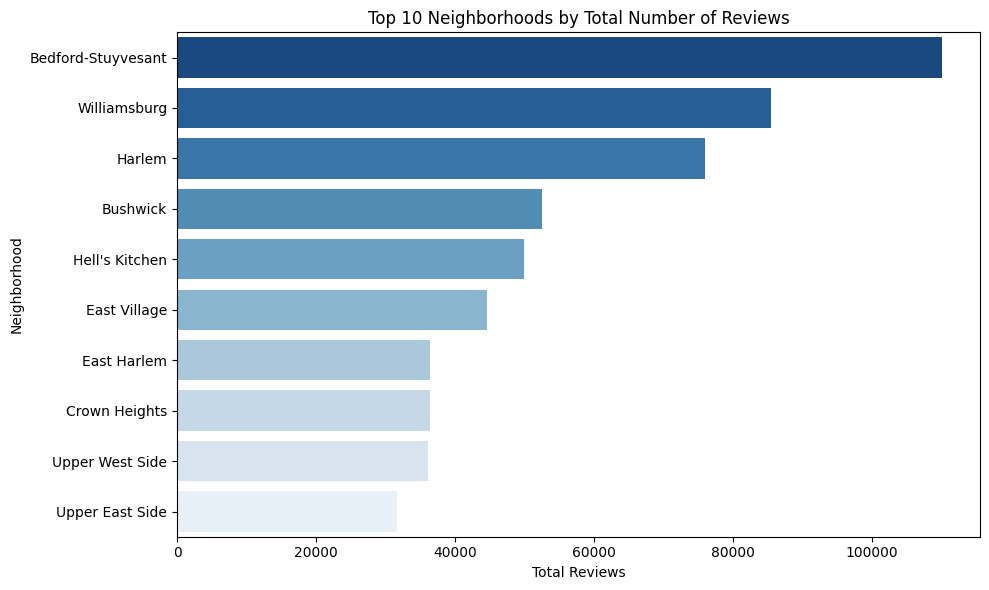

In [98]:
#Task 7 plot 2
#Group by neighborhood and sum reviews
reviews_by_neighborhood = df_clean.groupby('neighbourhood')['number_of_reviews'].sum().sort_values(ascending=False).head(10)

# plot the figues in a horizontal bar plot to show the neighborhoods by amount of reviews
plt.figure(figsize=(10, 6))
sns.barplot(x=reviews_by_neighborhood.values, y=reviews_by_neighborhood.index, palette='Blues_r')

#set labels for axis and graph
plt.title("Top 10 Neighborhoods by Total Number of Reviews")
plt.xlabel("Total Reviews")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()



For Task 7 Plot 2 
This bar chart shows the 10 most reviewed neighberhoods in New York City based on the number of guest reviews. This shows that neighborhoods with high review counts typically have more Airbnb traffic and a higher listing amount. This also shows the neighberhoods with the most  popularity for tourists or travelers.What I learned is some neighborhoods may not have the highest prices, but they receive a high amount of reviews possibly due to affordability and accessibility.This plot could help hosts decide which neighbourhoods to target for airbnb listings. 
